In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter
from sklearn.neural_network import MLPRegressor
import os

In [21]:
# plots config
%matplotlib inline
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['font.size'] = 12

In [23]:
# --- CONFIGURACIÓN ---
FILES = ['../datos_axel/rec1_001.csv', '../datos_axel/rec1_002.csv', '../datos_axel/rec1_003.csv']
R_s = 1.2       # Resistencia Estator [Ohm]
L_s = 2.05e-3   # Inductancia Estator [H]

In [24]:
# funcion para cargar datos
def load_dspace_robust_nb(filename):
    """
    Función optimizada para Notebooks.
    Lee archivos dSPACE ignorando encabezados basura.
    """
    if not os.path.exists(filename):
        print(f"⚠️ Archivo no encontrado: {filename}")
        return None
        
    print(f"📂 Procesando: {filename}...", end=" ")
    try:
        with open(filename, 'r', encoding='utf-8', errors='ignore') as f:
            lines = f.readlines()
        
        # 1. Buscar nombres de columnas
        header_idx = -1
        col_names = []
        for i, line in enumerate(lines):
            if line.startswith('trace_names'):
                header_idx = i
                parts = line.strip().split(',')
                # Limpiar nombres vacíos
                col_names = [p.strip() if p.strip() != '' else 'Time' for p in parts]
                if 'trace_names' in col_names: col_names.remove('trace_names')
                break
        
        if header_idx == -1: 
            print("-> [SALTADO: No hay header]")
            return None

        # 2. Buscar inicio de datos
        data_start = -1
        for i in range(header_idx + 1, len(lines)):
            line = lines[i].strip()
            if line.startswith(',') and len(line) > 5:
                try: 
                    float(line.split(',')[1])
                    data_start = i; break
                except: continue
        
        if data_start == -1: 
            print("-> [SALTADO: No hay datos]")
            return None

        # 3. Parsear datos
        data = []
        for line in lines[data_start:]:
            parts = line.strip().split(',')
            row_parts = parts[1:] if line.startswith(',') else parts
            
            row = []
            for p in row_parts:
                try: row.append(float(p))
                except: row.append(np.nan)
            if len(row) > 0: data.append(row)
            
        # 4. Crear DataFrame
        df = pd.DataFrame(data)
        width = min(len(col_names), df.shape[1])
        df = df.iloc[:, :width]
        df.columns = col_names[:width]
        
        clean_df = df.dropna()
        print(f"-> [OK: {len(clean_df)} filas]")
        return clean_df

    except Exception as e:
        print(f"-> [ERROR: {e}]")
        return None

In [25]:
# --- BUCLE PRINCIPAL ---
X_all, Y_all = [], []

print("--- INICIANDO EXTRACCIÓN DE DATOS ---")

for fname in FILES:
    df = load_dspace_robust_nb(fname)
    if df is None: continue
    
    try:
        # Extraer Señales
        t = df['Time'].values
        # Detectar columnas de corriente
        Id = df['Ds'].values if 'Ds' in df.columns else (df['Id'].values if 'Id' in df.columns else None)
        Iq = df['Qs'].values if 'Qs' in df.columns else (df['Iq'].values if 'Iq' in df.columns else None)
        
        if Id is None or Iq is None:
            print(f"   ⚠️ No se encontraron columnas Ds/Qs en {fname}")
            continue

        # Voltajes (Out1[0]..[2])
        v_cols = [c for c in df.columns if 'Out1[' in c]
        if len(v_cols) < 3:
            print(f"   ⚠️ No se encontraron Voltajes Out1 en {fname}")
            continue
        Va, Vb, Vc = df[v_cols[0]].values, df[v_cols[1]].values, df[v_cols[2]].values
        
        # Mecánica
        if 'speed' not in df.columns or 'Theta_e' not in df.columns:
            print(f"   ⚠️ Faltan datos mecánicos en {fname}")
            continue
            
        w_mech = df['speed'].values
        theta_e = df['Theta_e'].values
        
        # --- FÍSICA INVERSA ---
        # 1. Transformaciones
        I_alpha = Id * np.cos(theta_e) - Iq * np.sin(theta_e)
        I_beta  = Id * np.sin(theta_e) + Iq * np.cos(theta_e)
        
        V_alpha = (2/3) * (Va - 0.5*Vb - 0.5*Vc)
        V_beta  = (2/3) * (np.sqrt(3)/2 * Vb - np.sqrt(3)/2 * Vc)
        
        # 2. Derivadas Suaves
        dt = np.mean(np.diff(t))
        if dt <= 0 or np.isnan(dt): dt = 50e-6
        
        # Filtro Savitzky-Golay
        window = 21
        dIa = savgol_filter(I_alpha, window, 2, deriv=1, delta=dt)
        dIb = savgol_filter(I_beta, window, 2, deriv=1, delta=dt)
        Ia_f = savgol_filter(I_alpha, window, 2)
        Ib_f = savgol_filter(I_beta, window, 2)
        
        # 3. Cálculo de BEMF: E = V - Ri - Ldi/dt
        E_alpha = V_alpha - R_s*Ia_f - L_s*dIa
        E_beta  = V_beta  - R_s*Ib_f - L_s*dIb
        
        # 4. Normalización y Filtrado (Velocidad > 20 rad/s)
        mask = np.abs(w_mech) > 20.0 
        
        if np.sum(mask) > 100:
            features = np.column_stack((np.sin(theta_e[mask]), np.cos(theta_e[mask])))
            targets = np.column_stack((E_alpha[mask]/w_mech[mask], E_beta[mask]/w_mech[mask]))
            
            X_all.append(features)
            Y_all.append(targets)
            print(f"   ✅ Agregadas {len(features)} muestras válidas.")
        else:
            print(f"   ⚠️ Velocidad insuficiente (<20 rad/s) en este archivo.")
            
    except Exception as e:
        print(f"   ❌ Error procesando señales: {e}")

--- INICIANDO EXTRACCIÓN DE DATOS ---
📂 Procesando: ../datos_axel/rec1_001.csv... -> [OK: 5750 filas]
   ✅ Agregadas 5750 muestras válidas.
📂 Procesando: ../datos_axel/rec1_002.csv... -> [OK: 5099 filas]
   ✅ Agregadas 5099 muestras válidas.
📂 Procesando: ../datos_axel/rec1_003.csv... -> [OK: 4051 filas]
   ✅ Agregadas 4051 muestras válidas.



--- ENTRENANDO RED NEURONAL ---
🚀 Entrenamiento Completado. R2 Score: 0.99930


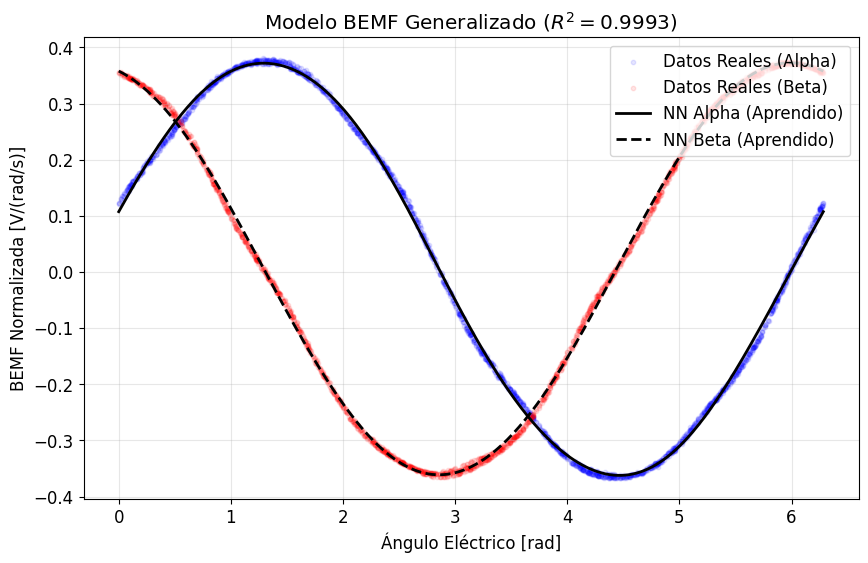

In [26]:
# --- ENTRENAMIENTO ---
if len(X_all) > 0:
    print("\n--- ENTRENANDO RED NEURONAL ---")
    X_train = np.vstack(X_all)
    Y_train = np.vstack(Y_all)
    
    # MLP Regressor
    nn = MLPRegressor(hidden_layer_sizes=(40, 40), activation='tanh', 
                      max_iter=500, random_state=42)
    nn.fit(X_train, Y_train)
    
    score = nn.score(X_train, Y_train)
    print(f"🚀 Entrenamiento Completado. R2 Score: {score:.5f}")
    
    # --- VISUALIZACIÓN ---
    # 1. Curva Aprendida
    th_plot = np.linspace(0, 2*np.pi, 360)
    X_plot = np.column_stack((np.sin(th_plot), np.cos(th_plot)))
    Y_pred = nn.predict(X_plot)
    
    plt.figure()
    
    # 2. Puntos Reales (Submuestreo)
    idx = np.random.choice(len(X_train), min(2000, len(X_train)), replace=False)
    th_scatter = np.arctan2(X_train[idx,0], X_train[idx,1]) % (2*np.pi)
    
    plt.scatter(th_scatter, Y_train[idx,0], s=10, c='b', alpha=0.1, label='Datos Reales (Alpha)')
    plt.scatter(th_scatter, Y_train[idx,1], s=10, c='r', alpha=0.1, label='Datos Reales (Beta)')
    
    plt.plot(th_plot, Y_pred[:,0], 'k-', linewidth=2, label='NN Alpha (Aprendido)')
    plt.plot(th_plot, Y_pred[:,1], 'k--', linewidth=2, label='NN Beta (Aprendido)')
    
    plt.title(f"Modelo BEMF Generalizado ($R^2={score:.4f}$)")
    plt.xlabel("Ángulo Eléctrico [rad]")
    plt.ylabel("BEMF Normalizada [V/(rad/s)]")
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3)
    plt.show()

else:
    print("\n❌ No hay suficientes datos para entrenar.")